In [91]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import numpy as np

# Topic Modelling and Sentiment Amalysis without automation

This pipeline scrapes the latest news related to Tesla (TSLA) from Finviz. I use the CardiffNLP RoBERTa model to classify sentiments as positive, negative, or neutral, and applies K-Means clustering on sentence embeddings generated by a SentenceTransformer to group news into distinct topics.

In [92]:
url = "https://finviz.com/quote.ashx?t=TSLA"
headers = {"User-Agent": "Mozilla/5.0"}

r = requests.get(url, headers=headers)
soup = BeautifulSoup(r.text, "html.parser")

table = soup.find("table", class_="fullview-news-outer")
rows = table.find_all("tr")

news_data = []
for row in rows:
    time = row.td.text if row.td else 'No time'
    headline = row.a.text if row.a else 'No headline'
    link = row.a["href"] if row.a else 'No link'

    news_data.append([time, headline, link])

news_df = pd.DataFrame(news_data, columns=["Time", "News", "Link"])

filename = '/tmp/tesla_finviz_news.csv'

news_df.to_csv(filename, index=False, encoding='utf-8')

print(f"\nNews total = {len(rows)}")
print(f"Data saved to {filename}")



News total = 103
Data saved to /tmp/tesla_finviz_news.csv


In [93]:
news_df

,Time,News,Link
0,\r\n May-01-25 11:28PM\r\n,Tesla (TSLA) Board Members Likely Held Unoffic...,/news/44862/tesla-tsla-board-members-likely-he...
1,\r\n 10:58PM\r\n,Franklin Rising Dividends SMA Q1 2025 Commentary,https://seekingalpha.com/article/4780921-frank...
2,\r\n 09:01PM\r\n,Tesla Chairwoman Files To Sell More Stock Cont...,https://finance.yahoo.com/news/tesla-chairwoma...
3,\r\n 09:01PM\r\n,Elon Musk's $100M Climate Gamble: Houston's Ma...,https://finance.yahoo.com/news/elon-musks-100m...
4,\r\n 07:49PM\r\n,Short Seller Jim Chanos Slams Tesla Robotaxi E...,https://finance.yahoo.com/news/short-seller-ji...
...,...,...,...
98,\r\n 02:42PM\r\n,"Trump Touts Wins, Musk Gets Applause as Cabine...",https://finance.yahoo.com/m/f0d8a1fb-fda2-3289...
99,\r\n 02:41PM\r\n,Tesla (TSLA) Gets Rare Insider Buy--but Board ...,https://finance.yahoo.com/news/tesla-tsla-gets...
100,\r\n 01:51PM\r\n,Top Founder-Run Company Stocks That Can Drive ...,/news/42074/top-founder-run-company-stocks-tha...
101,\r\n 01:12PM\r\n,"To sell its cars, Chinas Chery turns to a robo...",https://finance.yahoo.com/m/b5075764-9476-36cc...


In [94]:
news_df = pd.read_csv('/tmp/tesla_finviz_news.csv')

# clean column
news_df['Time'] = news_df['Time'].str.replace(r'\r\n', '', regex=True).str.strip()  # remove \r\n and space
news_df['News'] = news_df['News'].str.replace(r'\r\n', '', regex=True).str.strip()

news_df


,Time,News,Link
0,May-01-25 11:28PM,Tesla (TSLA) Board Members Likely Held Unoffic...,/news/44862/tesla-tsla-board-members-likely-he...
1,10:58PM,Franklin Rising Dividends SMA Q1 2025 Commentary,https://seekingalpha.com/article/4780921-frank...
2,09:01PM,Tesla Chairwoman Files To Sell More Stock Cont...,https://finance.yahoo.com/news/tesla-chairwoma...
3,09:01PM,Elon Musk's $100M Climate Gamble: Houston's Ma...,https://finance.yahoo.com/news/elon-musks-100m...
4,07:49PM,Short Seller Jim Chanos Slams Tesla Robotaxi E...,https://finance.yahoo.com/news/short-seller-ji...
...,...,...,...
98,02:42PM,"Trump Touts Wins, Musk Gets Applause as Cabine...",https://finance.yahoo.com/m/f0d8a1fb-fda2-3289...
99,02:41PM,Tesla (TSLA) Gets Rare Insider Buy--but Board ...,https://finance.yahoo.com/news/tesla-tsla-gets...
100,01:51PM,Top Founder-Run Company Stocks That Can Drive ...,/news/42074/top-founder-run-company-stocks-tha...
101,01:12PM,"To sell its cars, Chinas Chery turns to a robo...",https://finance.yahoo.com/m/b5075764-9476-36cc...


In [95]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [96]:
contractions_map = {
    "I'm": "I am",
    "can't": "cannot",
    "couldn't": "could not",
    "shouldn't": "should not",
    "don't": "do not",
    "doesn't": "does not",
    "won't": "will not",
    "can't": "cannot",
    "couldn't": "could not",
    "shouldn't": "should not",
    "mayn't": "may not",
    "mightn't": "might not",
    "shan't": "shall not",
}

def contractions(text):
    for contraction, expanded_form in contractions_map.items():
        text = text.replace(contraction, expanded_form)

    return text

# test contractions function
# text = "I'm happy I can't do it"
# output = contractions(text)
# print(output)

In [97]:
def preprocessing_text(text):

    # convert all texts to lowercase
    text = text.lower()

    # remove all numbers
    text = re.sub(r'\d+', '', text)

    # remove URLs
    text = re.sub(r'https?://\S+|\.com$', '', text)

    # remove flight number
    text = re.sub(r'\b[bB]\w*\d{3,}\w*\b', '', text)

    # remove HTML link
    text = re.sub(r'\<br /\>', r' ', text)

    # remove any word which have @ symbols such as email
    text = re.sub(r'@\w+', '', text)

    # remove symbols
    text = re.sub(r'[\.\!\?\$\%\#\;\:\-\&\@\+\=\_\"\'\,\)\(\*]*[\r\n]*', '', text)

    # expand contractions
    text = contractions(text)

    # tokenize text
    words = nltk.word_tokenize(text)

    # remove stopwords
    words = [word for word in words if word not in stopwords.words('english')]
    # print(words)

    # Lemmatize words
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    # join words into string
    text = ' '.join(words)
    return text


# # preprocess
processed_documents = [preprocessing_text(txt) for txt in news_df['News']]

In [98]:
processed_documents

['tesla tsla board member likely held unofficial talk replacing musk cnbc anchor say',
 'franklin rising dividend sma q commentary',
 'tesla chairwoman file sell stock continuing pattern insider sale ev giant',
 'elon musk climate gamble houston mati carbon win rock dust hack save farmer across continent',
 'short seller jim chanos slam tesla robotaxi economics ridiculous citing dead mile insurance cost cleaning expense',
 'headline',
 'elon musk asked car company suck said blow mind choose ugly expensive design good one cost',
 'elon musk say come surprise china economy surpasses u eu amid rising tariff growing recession fear',
 'analyst report tesla inc',
 'analysistesla without musk board face unique challenge whether stay go',
 'tesla europe sale plunge adding investor woe',
 'nothing happens tesla without musk knowing gerber',
 'byd keep dominating ev race china tesla face boycott risk',
 'amc earnings theater company turn around time meme stock buy',
 'nasdaq soar big tech earnin

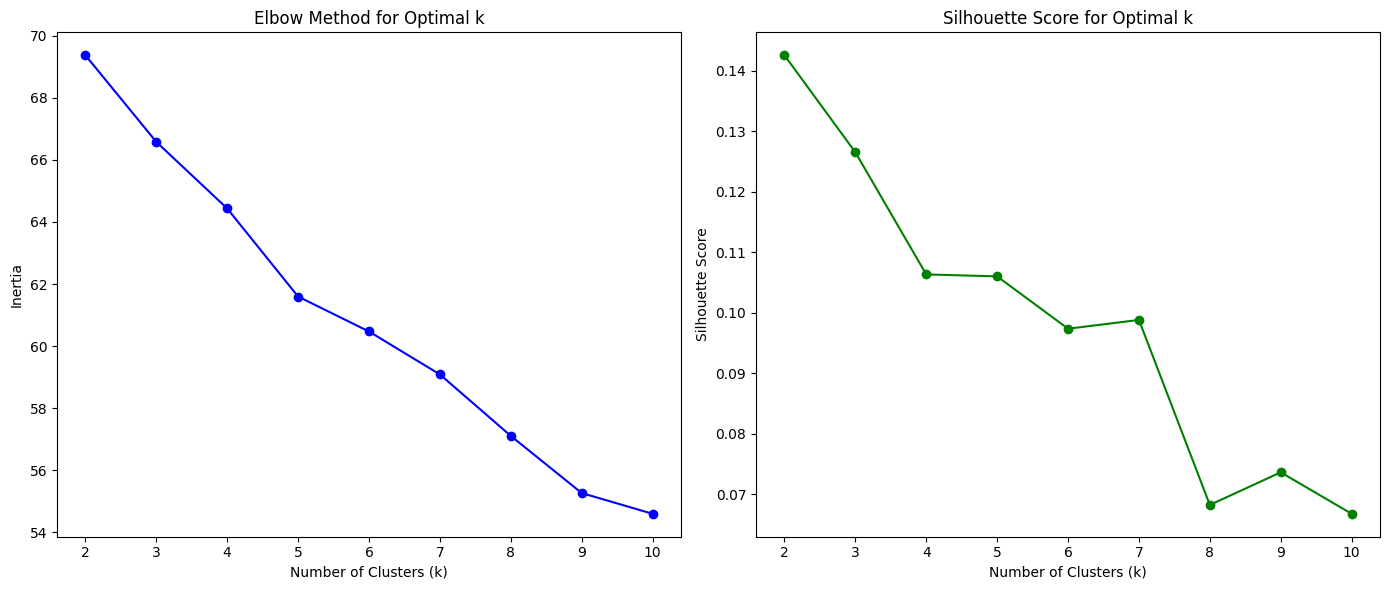

In [ ]:
# encode the documents with pre-trained BERT model
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(processed_documents)

# finding optimal k using Elbow Method
inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=10)
    kmeans.fit(embeddings)
    inertias.append(kmeans.inertia_)

    sil_score = silhouette_score(embeddings, kmeans.labels_, metric='cosine')
    sil_scores.append(sil_score)

plt.figure(figsize=(14, 6))

# Elbow Plot
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

# Silhouette Plot
plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, marker='o', color='g')
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [100]:
# choose optimal k based on both Elbow Method and Silhouette Score
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=10)
kmeans.fit(embeddings)

topics = kmeans.labels_

Top 10 words for Topic 0:
sale, insurance, bear, holding, humanoid, decline, challenge, new, magic, byd


Top 10 words for Topic 1:
reserve, save, profit, invited, affect, meta, rally, margin, chip, humanoid


Top 10 words for Topic 2:
reserve, humanoid, invited, chip, longtime, open, market, car, holding, lilly


Top 10 words for Topic 3:
chip, profit, deal, ross, rally, jim, famous, magic, challenge, meta


Top 10 words for Topic 4:
decline, magic, searching, profit, affect, drag, deal, sma, meta, humanoid




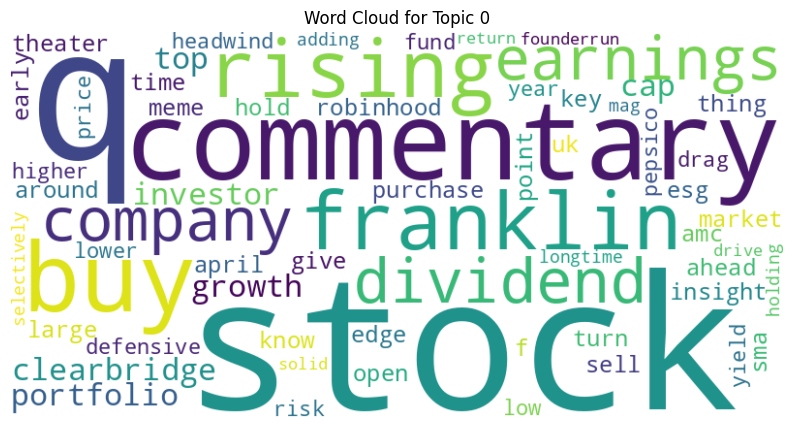

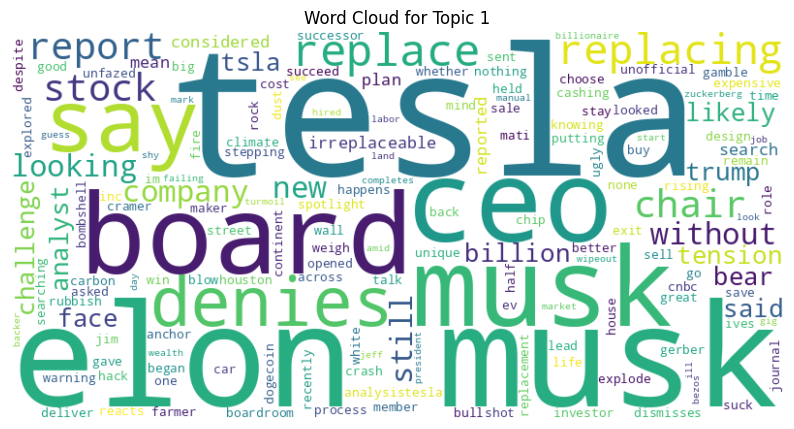

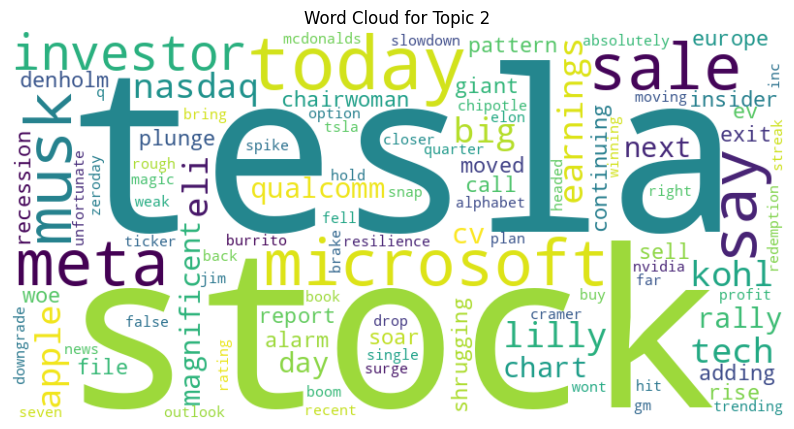

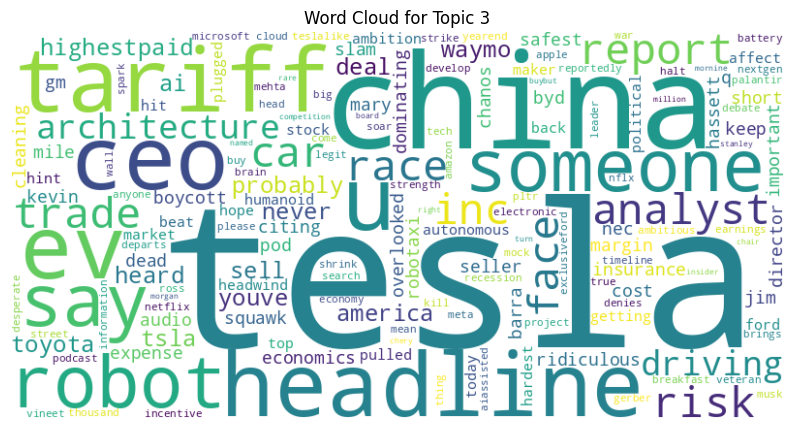

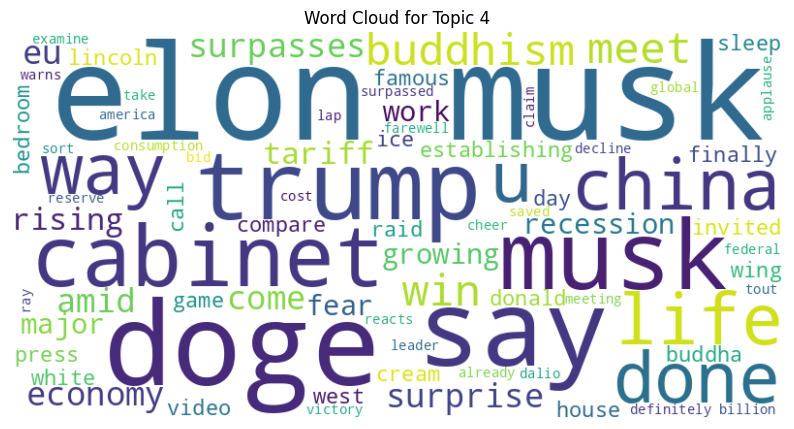

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(processed_documents)

feature_names = np.array(vectorizer.get_feature_names_out())

# get top 10 words for each cluster
top_n = 10
for i in range(optimal_k):
    cluster_center = kmeans.cluster_centers_[i]

    top_indices = cluster_center.argsort()[-top_n:][::-1]
    top_words = feature_names[top_indices]

    top_words_filtered = [word for word in top_words if not any(char.isdigit() for char in word)]

    print(f"Top {top_n} words for Topic {i}:")
    print(", ".join(top_words_filtered))
    print("\n" + "="*50 + "\n")

# generate Word Cloud for each cluster
for i in range(optimal_k):
    cluster_docs = np.array(processed_documents)[topics == i]

    cluster_text = " ".join(cluster_docs)

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(cluster_text)

    plt.figure(figsize=(10, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for Topic {i}")
    plt.show()


| Topic| Top Words| Topic Name|
|-------|----------------------------------------------------------------------------|---------------------------------------------|
| 0| sale, insurance, bear, holding, humanoid, decline, challenge, new, magic, byd| Emerging Tech Challenges|
| 1| reserve, save, profit, invited, affect, meta, rally, margin, chip, humanoid| Tech-Driven Investment|
| 2| reserve, humanoid, invited, chip, longtime, open, market, car, holding, lilly| Automotive in the Market
| 3| chip, profit, deal, ross, rally, jim, famous, magic, challenge, meta| High-Profile Tech Deals|
| 4| decline, magic, searching, profit, affect, drag, deal, sma, meta, humanoid| Tech Uncertainty|


In [102]:
# perform K-Means clustering with the optimal k (k=5)
kmeans = KMeans(n_clusters=optimal_k, random_state=10)
kmeans.fit(embeddings)

# get the cluster labels
topics = kmeans.labels_

In [103]:
news_df['topic'] = topics

In [104]:
topic_names = {
    0: "Emerging Tech Challenges",
    1: "Tech-Driven Investment",
    2: "Automotive in the Market",
    3: "High-Profile Tech Deals",
    4: "Tech Uncertainty"
}


news_df['topic_name'] = news_df['topic'].map(topic_names)

In [105]:
news_df

,Time,News,Link,topic,topic_name
0,May-01-25 11:28PM,Tesla (TSLA) Board Members Likely Held Unoffic...,/news/44862/tesla-tsla-board-members-likely-he...,1,Tech-Driven Investment
1,10:58PM,Franklin Rising Dividends SMA Q1 2025 Commentary,https://seekingalpha.com/article/4780921-frank...,0,Emerging Tech Challenges
2,09:01PM,Tesla Chairwoman Files To Sell More Stock Cont...,https://finance.yahoo.com/news/tesla-chairwoma...,2,Automotive in the Market
3,09:01PM,Elon Musk's $100M Climate Gamble: Houston's Ma...,https://finance.yahoo.com/news/elon-musks-100m...,1,Tech-Driven Investment
4,07:49PM,Short Seller Jim Chanos Slams Tesla Robotaxi E...,https://finance.yahoo.com/news/short-seller-ji...,3,High-Profile Tech Deals
...,...,...,...,...,...
98,02:42PM,"Trump Touts Wins, Musk Gets Applause as Cabine...",https://finance.yahoo.com/m/f0d8a1fb-fda2-3289...,4,Tech Uncertainty
99,02:41PM,Tesla (TSLA) Gets Rare Insider Buy--but Board ...,https://finance.yahoo.com/news/tesla-tsla-gets...,3,High-Profile Tech Deals
100,01:51PM,Top Founder-Run Company Stocks That Can Drive ...,/news/42074/top-founder-run-company-stocks-tha...,0,Emerging Tech Challenges
101,01:12PM,"To sell its cars, Chinas Chery turns to a robo...",https://finance.yahoo.com/m/b5075764-9476-36cc...,3,High-Profile Tech Deals


In [106]:
print(news_df['topic_name'].value_counts())


topic_name
Tech-Driven Investment      33
High-Profile Tech Deals     27
Automotive in the Market    19
Emerging Tech Challenges    12
Tech Uncertainty            12
Name: count, dtype: int64


In [107]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch

# pre-trained model
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# pipeline
sentiment_pipe = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)


Device set to use cpu


In [108]:
# test label
result = sentiment_pipe("I hate this product!")
print(result)


[{'label': 'LABEL_0', 'score': 0.9796938300132751}]


In [109]:
def analyze_sentiment_with_score(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return "neutral", 0.0
    try:
        result = sentiment_pipe(text[:512])[0]
        label = result['label'].lower()
        score = result['score']
        return label, score
    except:
        return "neutral", 0.0


In [110]:
news_df[['sentiment', 'score']] = news_df['News'].apply(lambda x: pd.Series(analyze_sentiment_with_score(x)))
news_df

,Time,News,Link,topic,topic_name,sentiment,score
0,May-01-25 11:28PM,Tesla (TSLA) Board Members Likely Held Unoffic...,/news/44862/tesla-tsla-board-members-likely-he...,1,Tech-Driven Investment,label_1,0.888847
1,10:58PM,Franklin Rising Dividends SMA Q1 2025 Commentary,https://seekingalpha.com/article/4780921-frank...,0,Emerging Tech Challenges,label_1,0.936946
2,09:01PM,Tesla Chairwoman Files To Sell More Stock Cont...,https://finance.yahoo.com/news/tesla-chairwoma...,2,Automotive in the Market,label_1,0.883160
3,09:01PM,Elon Musk's $100M Climate Gamble: Houston's Ma...,https://finance.yahoo.com/news/elon-musks-100m...,1,Tech-Driven Investment,label_1,0.561436
4,07:49PM,Short Seller Jim Chanos Slams Tesla Robotaxi E...,https://finance.yahoo.com/news/short-seller-ji...,3,High-Profile Tech Deals,label_0,0.717597
...,...,...,...,...,...,...,...
98,02:42PM,"Trump Touts Wins, Musk Gets Applause as Cabine...",https://finance.yahoo.com/m/f0d8a1fb-fda2-3289...,4,Tech Uncertainty,label_2,0.526629
99,02:41PM,Tesla (TSLA) Gets Rare Insider Buy--but Board ...,https://finance.yahoo.com/news/tesla-tsla-gets...,3,High-Profile Tech Deals,label_1,0.620047
100,01:51PM,Top Founder-Run Company Stocks That Can Drive ...,/news/42074/top-founder-run-company-stocks-tha...,0,Emerging Tech Challenges,label_2,0.753908
101,01:12PM,"To sell its cars, Chinas Chery turns to a robo...",https://finance.yahoo.com/m/b5075764-9476-36cc...,3,High-Profile Tech Deals,label_1,0.864722


In [111]:
label_map = {
    "label_0": "negative",
    "label_1": "neutral",
    "label_2": "positive"
}

news_df['sentiment'] = news_df['sentiment'].map(lambda x: label_map.get(x, x))

news_df

,Time,News,Link,topic,topic_name,sentiment,score
0,May-01-25 11:28PM,Tesla (TSLA) Board Members Likely Held Unoffic...,/news/44862/tesla-tsla-board-members-likely-he...,1,Tech-Driven Investment,neutral,0.888847
1,10:58PM,Franklin Rising Dividends SMA Q1 2025 Commentary,https://seekingalpha.com/article/4780921-frank...,0,Emerging Tech Challenges,neutral,0.936946
2,09:01PM,Tesla Chairwoman Files To Sell More Stock Cont...,https://finance.yahoo.com/news/tesla-chairwoma...,2,Automotive in the Market,neutral,0.883160
3,09:01PM,Elon Musk's $100M Climate Gamble: Houston's Ma...,https://finance.yahoo.com/news/elon-musks-100m...,1,Tech-Driven Investment,neutral,0.561436
4,07:49PM,Short Seller Jim Chanos Slams Tesla Robotaxi E...,https://finance.yahoo.com/news/short-seller-ji...,3,High-Profile Tech Deals,negative,0.717597
...,...,...,...,...,...,...,...
98,02:42PM,"Trump Touts Wins, Musk Gets Applause as Cabine...",https://finance.yahoo.com/m/f0d8a1fb-fda2-3289...,4,Tech Uncertainty,positive,0.526629
99,02:41PM,Tesla (TSLA) Gets Rare Insider Buy--but Board ...,https://finance.yahoo.com/news/tesla-tsla-gets...,3,High-Profile Tech Deals,neutral,0.620047
100,01:51PM,Top Founder-Run Company Stocks That Can Drive ...,/news/42074/top-founder-run-company-stocks-tha...,0,Emerging Tech Challenges,positive,0.753908
101,01:12PM,"To sell its cars, Chinas Chery turns to a robo...",https://finance.yahoo.com/m/b5075764-9476-36cc...,3,High-Profile Tech Deals,neutral,0.864722


In [112]:
sentiment_distribution = news_df['sentiment'].value_counts()
sentiment_distribution

,count
sentiment,
neutral,78
positive,16
negative,9


In [113]:
average_score = news_df['score'].mean()
print(f"Avg Sentiment Score: {average_score}")

Avg Sentiment Score: 0.7161914940597942


# Data Pipeline

In [ ]:
def scrape_data():
    url = "https://finviz.com/quote.ashx?t=TSLA"
    headers = {"User-Agent": "Mozilla/5.0"}

    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    table = soup.find("table", class_="fullview-news-outer")
    rows = table.find_all("tr")

    news_data = []
    for row in rows:
        time = row.td.text if row.td else 'No time'
        headline = row.a.text if row.a else 'No headline'
        link = row.a["href"] if row.a else 'No link'

        news_data.append([time, headline, link])

    news_df = pd.DataFrame(news_data, columns=["Time", "News", "Link"])

    news_df['Time'] = news_df['Time'].str.replace(r'\r\n', '', regex=True).str.strip()  # remove \r\n and space
    news_df['News'] = news_df['News'].str.replace(r'\r\n', '', regex=True).str.strip()

    return news_df

contractions_map = {
    "I'm": "I am",
    "can't": "cannot",
    "couldn't": "could not",
    "shouldn't": "should not",
    "don't": "do not",
    "doesn't": "does not",
    "won't": "will not",
    "can't": "cannot",
    "couldn't": "could not",
    "shouldn't": "should not",
    "mayn't": "may not",
    "mightn't": "might not",
    "shan't": "shall not",
}

def contractions(text):
    for contraction, expanded_form in contractions_map.items():
        text = text.replace(contraction, expanded_form)

    return text


def preprocessing_text(text):
    # convert all texts to lowercase
    text = text.lower()

    # remove all numbers
    text = re.sub(r'\d+', '', text)

    # remove URLs
    text = re.sub(r'https?://\S+|\.com$', '', text)

    # remove flight number
    text = re.sub(r'\b[bB]\w*\d{3,}\w*\b', '', text)

    # remove HTML link
    text = re.sub(r'\<br /\>', r' ', text)

    # remove any word which have @ symbols such as email
    text = re.sub(r'@\w+', '', text)

    # remove symbols
    text = re.sub(r'[\.\!\?\$\%\#\;\:\-\&\@\+\=\_\"\'\,\)\(\*]*[\r\n]*', '', text)

    # expand contractions
    text = contractions(text)

    # tokenize text
    words = nltk.word_tokenize(text)

    # remove stopwords
    words = [word for word in words if word not in stopwords.words('english')]
    # print(words)

    # Lemmatize words
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    # join words into string
    text = ' '.join(words)
    return text

def preprocess_news(news_df):
    news_df['News'] = news_df['News'].apply(preprocessing_text)
    return news_df

def sentiment_analysis(news_df):
    model_name = "cardiffnlp/twitter-roberta-base-sentiment"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)

    # pipeline
    sentiment_pipe = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

    def analyze_sentiment_with_score(text):
        if not isinstance(text, str) or len(text.strip()) == 0:
            return "neutral", 0.0
        try:
            result = sentiment_pipe(text[:512])[0]
            label = result['label'].lower()
            score = result['score']
            return label, score
        except:
            return "neutral", 0.0

    news_df[['sentiment', 'score']] = news_df['News'].apply(lambda x: pd.Series(analyze_sentiment_with_score(x)))



    label_map = {
    "label_0": "negative",
    "label_1": "neutral",
    "label_2": "positive"
    }

    news_df['sentiment'] = news_df['sentiment'].map(lambda x: label_map.get(x, x))

    return news_df

def clustering(news_df):
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode(news_df['News'].tolist())

    # K-Means clustering
    kmeans = KMeans(n_clusters=5, random_state=10)
    kmeans.fit(embeddings)
    topics = kmeans.labels_

    news_df['topic'] = topics
    return news_df

def save_to_csv(news_df, filename):
    news_df.to_csv(filename, index=False, encoding='utf-8')
    print(f"Data saved to {filename}")

def build_pipeline():
    # scrape data
    news_df = scrape_data()

    # preprocess data
    news_df = preprocess_news(news_df)

    # Sentiment Analysis
    news_df = sentiment_analysis(news_df)

    # clustering
    news_df = clustering(news_df)

    # save
    filename = '/tmp/tesla_news_pipeline.csv'
    save_to_csv(news_df, filename)

    return news_df

# run pipeline
news_df = build_pipeline()


Device set to use cpu


Data saved to /tmp/tesla_news_pipeline.csv


In [115]:
news_df


,Time,News,Link,sentiment,score,topic
0,May-01-25 11:28PM,tesla tsla board member likely held unofficial...,/news/44862/tesla-tsla-board-members-likely-he...,neutral,0.942866,1
1,10:58PM,franklin rising dividend sma q commentary,https://seekingalpha.com/article/4780921-frank...,neutral,0.901005,0
2,09:01PM,tesla chairwoman file sell stock continuing pa...,https://finance.yahoo.com/news/tesla-chairwoma...,neutral,0.835480,2
3,09:01PM,elon musk climate gamble houston mati carbon w...,https://finance.yahoo.com/news/elon-musks-100m...,neutral,0.776276,1
4,07:49PM,short seller jim chanos slam tesla robotaxi ec...,https://finance.yahoo.com/news/short-seller-ji...,negative,0.804524,3
...,...,...,...,...,...,...
98,02:42PM,trump tout win musk get applause cabinet meet,https://finance.yahoo.com/m/f0d8a1fb-fda2-3289...,neutral,0.753652,4
99,02:41PM,tesla tsla get rare insider buybut board chair...,https://finance.yahoo.com/news/tesla-tsla-gets...,neutral,0.886245,3
100,01:51PM,top founderrun company stock drive solid return,/news/42074/top-founder-run-company-stocks-tha...,positive,0.784943,0
101,01:12PM,sell car china chery turn robot named mornine,https://finance.yahoo.com/m/b5075764-9476-36cc...,neutral,0.871709,3


In [117]:
sentiment_by_topic = news_df.groupby(['topic', 'sentiment']).size().unstack().fillna(0)
sentiment_by_topic


sentiment,negative,neutral,positive
topic,,,
0,0.0,11.0,1.0
1,1.0,31.0,1.0
2,5.0,11.0,3.0
3,2.0,25.0,0.0
4,0.0,11.0,1.0
